# Conditional Monte Carlo rollouts for the consistent graph model

*Iris Seaman · I-SPY 2 / ACRIN-6698 · consistent-graph rollout model*

---

## What this notebook is

This notebook is the readable version of the Monte Carlo experiment we added for the **registered consistent-graph rollout model**. The goal is not to introduce a new model. The goal is to take the current best deterministic rollout model and ask a more honest question:

> Given what we have observed for this patient so far, what range of tumor futures are still plausible, especially for functional tumor volume (FTV)?

The key experiment is **start-time conditional**:

- **T0 observed** → predict T1, T2, T3
- **T0 and T1 observed** → predict T2, T3
- **T0, T1, and T2 observed** → predict T3

The hypothesis is simple: as we condition on more observed treatment response, the future should become less uncertain. In particular, the T3 interval from T2 should usually be narrower and better calibrated than the T3 interval from T0.

## Where Section 3 fits

Section 3 is what makes this possible. After registration, each patient has all treatment visits in one coordinate system. The **dynamic contrast-enhanced magnetic resonance imaging (DCE-MRI)** volumes are aligned, and the **simple linear iterative clustering (SLIC)** supervoxels give us consistent graph nodes that can be followed across T0, T1, T2, and T3.

So in this notebook I am not re-building the imaging pipeline. I am starting from the registered consistent graphs and asking: once the model has observed a patient through visit $s$, how uncertain should we be about each later visit $t$?

That distinction matters:

- registration gives a shared patient-specific geometry,
- the scheduled-sampling rollout model gives the deterministic mean future,
- Monte Carlo sampling turns that mean future into a calibrated distribution of plausible futures.

## Big picture

The simulation is **within-patient uncertainty**, not between-patient variability.

For each patient, the rollout model gives one mean future. We then generate many plausible versions of that same patient's future by sampling errors that the model made on other held-out patients. After that, we summarize the distribution for that patient.

Only after the patient-level distributions are built do we aggregate across the cohort.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "datasets").exists() and (p / "experiments").exists():
            return p
    # Fallback for opening directly from notebooks/ispy2 before the cwd is set.
    candidate = Path("/Users/irisseaman/Research/3DGCNN")
    if candidate.exists():
        return candidate
    raise RuntimeError("Could not locate the 3DGCNN repo root")


ROOT = find_repo_root()
REPORT_CANDIDATES = [
    ROOT / "reports" / "conditional_mc_consistent_rollout",
    ROOT / "reports" / "conditional_mc_consistent_rollout_smoke",
]


def pick_report_dir() -> Path:
    for p in REPORT_CANDIDATES:
        if (p / "conditional_mc_per_patient.parquet").exists():
            return p
    raise FileNotFoundError(
        "No conditional MC report found. Run experiments/consistent_rollout/run_conditional_mc.py first."
    )


REPORT_DIR = pick_report_dir()
print(f"Repo root:  {ROOT}")
print(f"Report dir: {REPORT_DIR}")

Repo root:  /Users/irisseaman/Research/3DGCNN
Report dir: /Users/irisseaman/Research/3DGCNN/reports/conditional_mc_consistent_rollout_smoke


## Experiment setup diagram

This is the picture I want people to have in their heads. The model is deterministic, but we surround it with a residual-calibrated Monte Carlo layer.

The retrospective evaluation is held-out: a patient in fold *f* is scored using the fold-*f* checkpoint, so the checkpoint did not train on that patient.

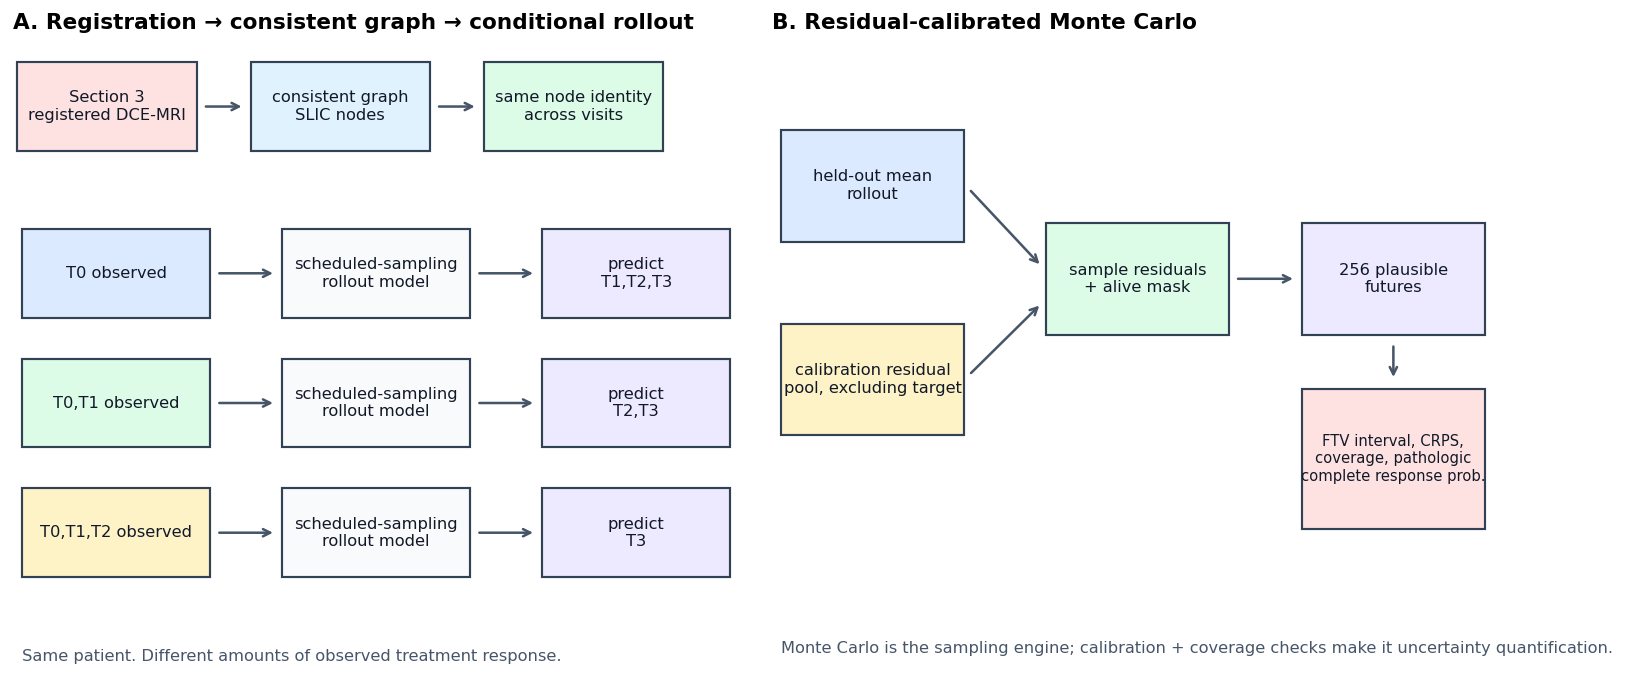

In [2]:
def draw_box(ax, xy, text, w=1.95, h=0.72, fc="#f8fafc", ec="#334155", fontsize=9):
    x, y = xy
    patch = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, linewidth=1.2)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, color="#111827", wrap=True)
    return patch


def arrow(ax, a, b, color="#475569"):
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle="->", lw=1.4, color=color, shrinkA=4, shrinkB=4))


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

ax = axes[0]
ax.set_title("A. Registration → consistent graph → conditional rollout", loc="left", fontweight="bold")
draw_box(ax, (0.05, 4.25), "Section 3\nregistered DCE-MRI", w=2.0, fc="#fee2e2")
draw_box(ax, (2.65, 4.25), "consistent graph\nSLIC nodes", w=2.0, fc="#e0f2fe")
draw_box(ax, (5.25, 4.25), "same node identity\nacross visits", w=2.0, fc="#dcfce7")
arrow(ax, (2.07, 4.61), (2.63, 4.61))
arrow(ax, (4.67, 4.61), (5.23, 4.61))

for i, (label, color, futures) in enumerate([
    ("T0 observed", "#dbeafe", "predict\nT1,T2,T3"),
    ("T0,T1 observed", "#dcfce7", "predict\nT2,T3"),
    ("T0,T1,T2 observed", "#fef3c7", "predict\nT3"),
]):
    y = 2.9 - i * 1.05
    draw_box(ax, (0.1, y), label, w=2.1, fc=color)
    draw_box(ax, (3.0, y), "scheduled-sampling\nrollout model", w=2.1, fc="#f8fafc")
    draw_box(ax, (5.9, y), futures, w=2.1, fc="#ede9fe")
    arrow(ax, (2.22, y + 0.36), (2.98, y + 0.36))
    arrow(ax, (5.12, y + 0.36), (5.88, y + 0.36))
ax.text(0.1, 0.12, "Same patient. Different amounts of observed treatment response.", fontsize=9, color="#475569")
ax.set_xlim(0, 8.2)
ax.set_ylim(0, 5.15)
ax.axis("off")

ax = axes[1]
ax.set_title("B. Residual-calibrated Monte Carlo", loc="left", fontweight="bold")
draw_box(ax, (0.1, 2.8), "held-out mean\nrollout", w=2.0, fc="#dbeafe")
draw_box(ax, (0.1, 1.55), "calibration residual\npool, excluding target", w=2.0, fc="#fef3c7")
draw_box(ax, (3.0, 2.2), "sample residuals\n+ alive mask", w=2.0, fc="#dcfce7")
draw_box(ax, (5.8, 2.2), "256 plausible\nfutures", w=2.0, fc="#ede9fe")
draw_box(ax, (5.8, 0.95), "FTV interval, CRPS,\ncoverage, pathologic\ncomplete response prob.", w=2.0, h=0.9, fc="#fee2e2", fontsize=8.2)
arrow(ax, (2.12, 3.16), (2.98, 2.62))
arrow(ax, (2.12, 1.92), (2.98, 2.42))
arrow(ax, (5.02, 2.56), (5.78, 2.56))
arrow(ax, (6.8, 2.17), (6.8, 1.88))
ax.text(0.1, 0.15, "Monte Carlo is the sampling engine; calibration + coverage checks make it uncertainty quantification.", fontsize=9, color="#475569")
ax.set_xlim(0, 8.05)
ax.set_ylim(0, 4.1)
ax.axis("off")

plt.tight_layout()
plt.show()

## The math, compact version

For patient $i$, let $G_{i,0:s}$ be the observed consistent graph history through visit $s$. The deterministic rollout model gives a mean prediction for a future visit $t$:

$$
\widehat{Y}_{i,t}^{(s)} = f_\theta(G_{i,0:s}), \qquad s < t
$$

where the prediction contains:

$$
\widehat{Y}_{i,t}^{(s)} = \{\widehat{P}_{j}, \widehat{X}_{j}, \widehat{a}_{j}\}_{j=1}^{N_i}
$$

- $\widehat{P}_{j}$: predicted 3D centroid for supervoxel $j$
- $\widehat{X}_{j}$: predicted node features, including volume
- $\widehat{a}_{j}$: predicted probability that supervoxel $j$ is alive

For each conditioning pair $(s,t)$, we build a residual library from other held-out patients:

$$
\mathcal{R}_{s,t}^{(-i)} = \{r_k : k \neq i\}
$$

Each Monte Carlo draw samples from this residual library:

$$
K^{(m)} = \mathrm{clip}\left(\mathrm{round}\left(\sum_j \widehat{a}_j + r_{\mathrm{alive}}^{(m)}\right), 0, N_i\right)
$$

Then we sample exactly $K^{(m)}$ alive supervoxels using Gumbel-top-$k$ sampling from the alive logits:

$$
A^{(m)} = \mathrm{GumbelTopK}(\mathrm{logit}(\widehat{a}), K^{(m)})
$$

For geometry, each sampled future gets a patient-level drift error and local supervoxel errors:

$$
P_j^{(m)} = \widehat{P}_j + b^{(m)} + \epsilon_j^{(m)}
$$

For volume, we perturb on the log scale so volumes stay positive after transforming back:

$$
V_j^{(m)} = \exp\left(\log(1 + \widehat{V}_j) + \eta_j^{(m)}\right) - 1
$$

Finally, the sampled functional tumor volume is:

$$
\mathrm{FTV}_{i,t}^{(m)} = \max\left(0, \sum_{j \in A^{(m)}} V_j^{(m)} + r_{\mathrm{FTV}}^{(m)}\right)
$$

So one patient now has a distribution of possible FTV values, geometries, and alive supervoxel sets.

## Monte Carlo vs uncertainty quantification

These are related, but they are not the same thing.

- **Monte Carlo simulation** is the sampling procedure: generate many plausible futures.
- **Uncertainty quantification** is the statistical claim: do the intervals actually cover the truth, and are they useful?

That is why this experiment reports coverage and the continuous ranked probability score (CRPS). A sample cloud by itself is not enough. The samples have to be calibrated against held-out patients.

## Load the report artifacts

The notebook will use the full report if it exists. Otherwise it falls back to the local smoke report, which is useful for checking the notebook mechanics but should not be interpreted scientifically.

In [3]:
samples = pd.read_parquet(REPORT_DIR / "conditional_mc_samples.parquet")
per_patient = pd.read_parquet(REPORT_DIR / "conditional_mc_per_patient.parquet")
summary = json.loads((REPORT_DIR / "conditional_mc_summary.json").read_text())
calibration = json.loads((REPORT_DIR / "conditional_mc_calibration.json").read_text())

meta = summary.get("metadata", {})
print("Report metadata")
for k in ["model_family", "n_patients", "n_rollout_records", "n_mc", "interval", "device", "leakage_policy"]:
    print(f"  {k}: {meta.get(k)}")

if REPORT_DIR.name.endswith("smoke"):
    display(Markdown("**Note:** this is the smoke report. Use it for notebook validation only, not final scientific claims."))

print("\nShapes")
print("  samples:    ", samples.shape)
print("  per_patient:", per_patient.shape)

display(
    per_patient[["start_visit", "predicted_visit", "patient_id"]]
    .groupby(["start_visit", "predicted_visit"])
    .nunique()
    .rename(columns={"patient_id": "n_patients"})
)

Report metadata
  model_family: consistent_graph_scheduled_sampling_rollout
  n_patients: 3
  n_rollout_records: 18
  n_mc: 8
  interval: 0.9
  device: cpu
  leakage_policy: each patient scored with its held-out fold checkpoint; calibration residuals exclude target patient


**Note:** this is the smoke report. Use it for notebook validation only, not final scientific claims.


Shapes
  samples:     (144, 16)
  per_patient: (18, 38)


n_patients
start_visit predicted_visit            
T0          T1                        3
            T2                        3
            T3                        3
T1          T2                        3
            T3                        3
T2          T3                        3

## Hypothesis check 1: T3 uncertainty should shrink with later conditioning

This is the main plot I care about. For the same final horizon, T3, the interval should generally get narrower as we move from T0-only to T0+T1 to T0+T1+T2 conditioning.

I am looking at both raw Monte Carlo intervals and conformal intervals. The conformal interval is the more defensible one because it has an explicit calibration step.

,raw_width,conformal_width,crps,ftv_abs_err,n
start_visit,,,,,
T0,9.580661,24.345820,8.372413,10.278166,3
T1,9.306407,27.426817,7.155007,8.957817,3
T2,10.764122,28.987567,11.329326,13.600036,3


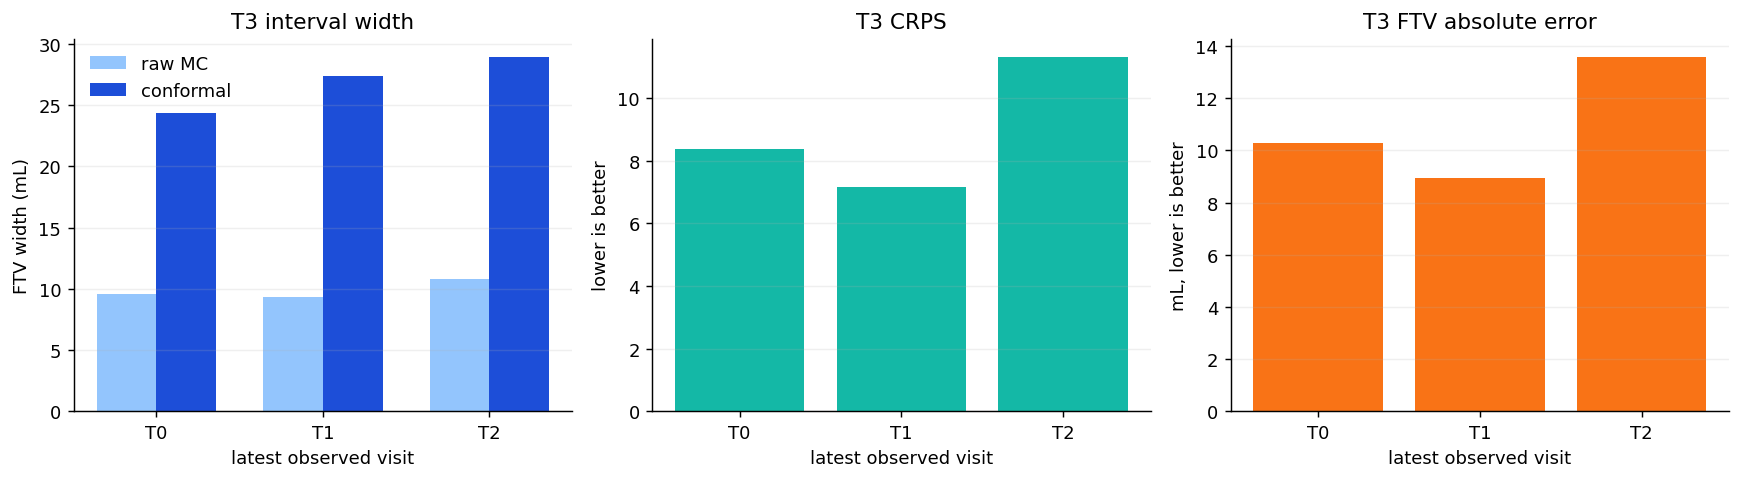

In [4]:
ORDER = ["T0", "T1", "T2"]
t3 = per_patient[per_patient["predicted_visit"] == "T3"].copy()
t3["start_visit"] = pd.Categorical(t3["start_visit"], ORDER, ordered=True)

plot_df = (
    t3.groupby("start_visit", observed=True)
    .agg(
        raw_width=("ftv_raw_width90_ml", "mean"),
        conformal_width=("ftv_conformal_width90_ml", "mean"),
        crps=("crps_ftv", "mean"),
        ftv_abs_err=("ftv_abs_err_ml_mc_mean", "mean"),
        n=("patient_id", "nunique"),
    )
    .reindex(ORDER)
)
display(plot_df)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
x = np.arange(len(plot_df.index))
axes[0].bar(x - 0.18, plot_df["raw_width"], width=0.36, label="raw MC", color="#93c5fd")
axes[0].bar(x + 0.18, plot_df["conformal_width"], width=0.36, label="conformal", color="#1d4ed8")
axes[0].set_title("T3 interval width")
axes[0].set_ylabel("FTV width (mL)")
axes[0].set_xticks(x, plot_df.index)
axes[0].legend(frameon=False)

axes[1].bar(x, plot_df["crps"], color="#14b8a6")
axes[1].set_title("T3 CRPS")
axes[1].set_ylabel("lower is better")
axes[1].set_xticks(x, plot_df.index)

axes[2].bar(x, plot_df["ftv_abs_err"], color="#f97316")
axes[2].set_title("T3 FTV absolute error")
axes[2].set_ylabel("mL, lower is better")
axes[2].set_xticks(x, plot_df.index)

for ax in axes:
    ax.set_xlabel("latest observed visit")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Hypothesis check 2: coverage and calibration

If the raw Monte Carlo samples are too narrow, raw coverage will be low. The conformal correction should widen intervals enough to improve coverage.

This is the part that makes the simulation an uncertainty-quantification experiment rather than just a visualization.

,start_visit,predicted_visit,n_unique_patients,raw_coverage90_ftv,conformal_coverage90_ftv,mean_conformal_q_ml,mean_crps_ftv
0,T0,T1,3,0.666667,0.666667,8.967786,7.525444
1,T0,T2,3,0.666667,0.666667,12.260655,11.105968
2,T0,T3,3,0.000000,0.666667,7.382580,8.372413
3,T1,T2,3,0.666667,0.666667,11.056949,7.502055
4,T1,T3,3,0.000000,0.666667,9.060205,7.155007
5,T2,T3,3,0.000000,0.666667,9.111723,11.329326


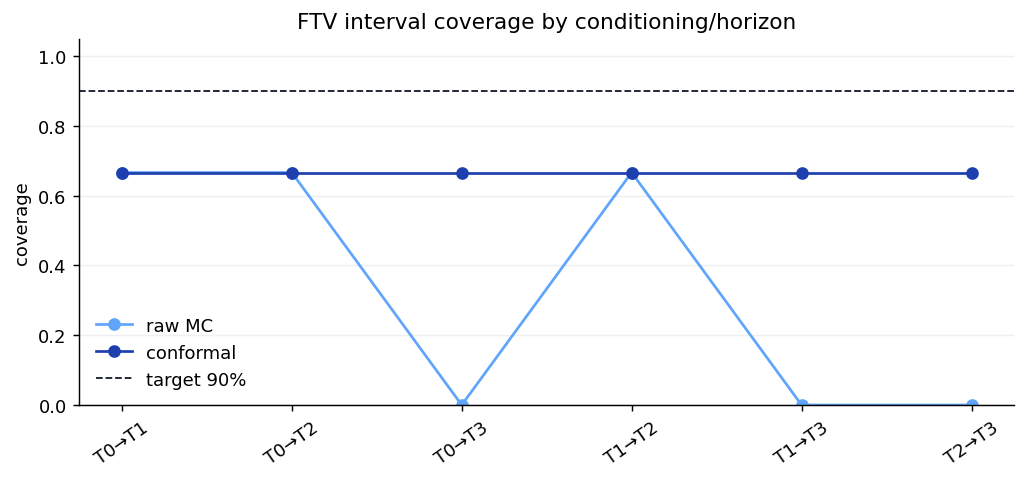

In [5]:
calib_rows = pd.DataFrame(calibration.get("residual_buckets", []))
if not calib_rows.empty:
    keep = [
        "start_visit", "predicted_visit", "n_unique_patients",
        "raw_coverage90_ftv", "conformal_coverage90_ftv",
        "mean_conformal_q_ml", "mean_crps_ftv",
    ]
    display(calib_rows[keep].sort_values(["start_visit", "predicted_visit"]))
else:
    display(Markdown("No calibration rows found."))

fig, ax = plt.subplots(figsize=(8, 3.8))
if not calib_rows.empty:
    tmp = calib_rows.copy()
    tmp["condition"] = tmp["start_visit"] + "→" + tmp["predicted_visit"]
    ax.plot(tmp["condition"], tmp["raw_coverage90_ftv"], marker="o", label="raw MC", color="#60a5fa")
    ax.plot(tmp["condition"], tmp["conformal_coverage90_ftv"], marker="o", label="conformal", color="#1e40af")
    ax.axhline(0.90, color="#111827", linestyle="--", linewidth=1, label="target 90%")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("coverage")
    ax.set_title("FTV interval coverage by conditioning/horizon")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Patient-level view: distributions, not just point predictions

For a single patient, the output is a distribution of possible FTV outcomes. This is the most important conceptual point: we are not drawing different patients; we are drawing different plausible futures for the same patient.

/var/folders/zk/pf3c6qjn4m52dj8wzflhtgk80000gn/T/ipykernel_63900/2994992477.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=ORDER, showfliers=False, patch_artist=True,
/var/folders/zk/pf3c6qjn4m52dj8wzflhtgk80000gn/T/ipykernel_63900/2994992477.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=ORDER, showfliers=False, patch_artist=True,
/var/folders/zk/pf3c6qjn4m52dj8wzflhtgk80000gn/T/ipykernel_63900/2994992477.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=ORDER, showfliers=False, patch_artist=True,


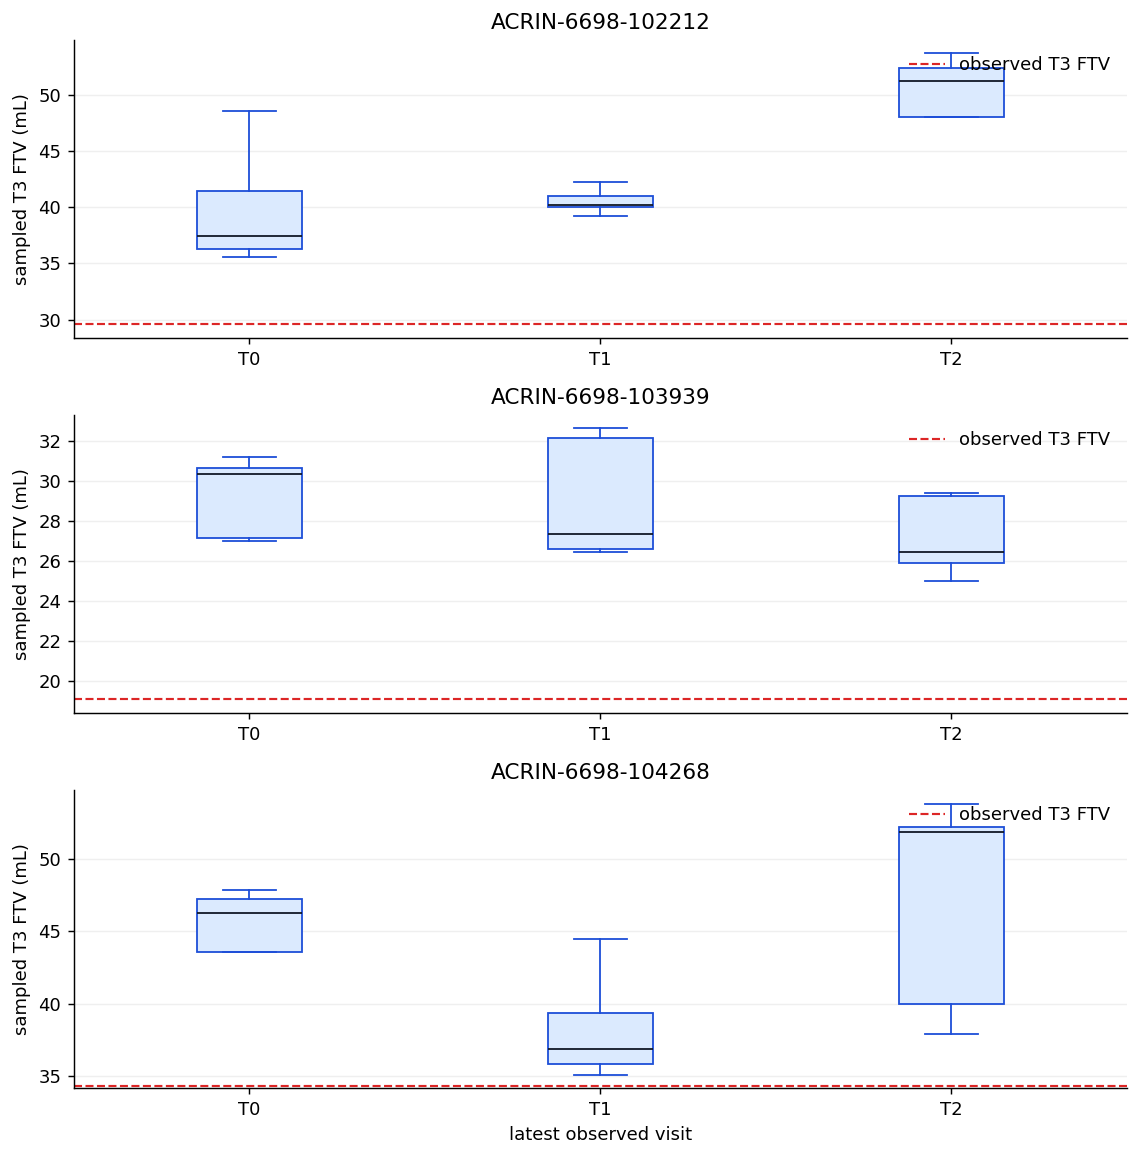

In [6]:
t3_samples = samples[samples["predicted_visit"] == "T3"].copy()
if t3_samples.empty:
    display(Markdown("No T3 sample rows available."))
else:
    # Pick a few patients with all three T3 conditioning paths.
    counts = t3_samples.groupby("patient_id")["start_visit"].nunique().sort_values(ascending=False)
    chosen = counts[counts >= min(3, counts.max())].index[:3].tolist()
    if not chosen:
        chosen = counts.index[:3].tolist()

    fig, axes = plt.subplots(len(chosen), 1, figsize=(9, 3.0 * len(chosen)), sharex=False)
    if len(chosen) == 1:
        axes = [axes]
    for ax, pid in zip(axes, chosen):
        sub = t3_samples[t3_samples["patient_id"] == pid]
        data = [sub.loc[sub["start_visit"] == s, "ftv_sample_ml"].to_numpy() for s in ORDER]
        ax.boxplot(data, labels=ORDER, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor="#dbeafe", color="#1d4ed8"),
                   medianprops=dict(color="#111827"),
                   whiskerprops=dict(color="#1d4ed8"), capprops=dict(color="#1d4ed8"))
        obs = per_patient[(per_patient["patient_id"] == pid) & (per_patient["predicted_visit"] == "T3")]
        if len(obs):
            ax.axhline(float(obs["obs_ftv_ml"].iloc[0]), color="#dc2626", linestyle="--", linewidth=1.2, label="observed T3 FTV")
        ax.set_title(pid)
        ax.set_ylabel("sampled T3 FTV (mL)")
        ax.grid(axis="y", alpha=0.2)
        ax.legend(frameon=False, loc="upper right")
    axes[-1].set_xlabel("latest observed visit")
    plt.tight_layout()
    plt.show()

## What I hope to see

The cleanest result would be:

1. **Intervals shrink with more observed visits**: T0→T3 should be widest, T2→T3 should be narrowest.
2. **CRPS improves with more observed visits**: the distribution should get sharper and closer to the truth.
3. **Conformal coverage is near 90%**: if raw Monte Carlo is under-covered, conformal intervals should fix that.
4. **pathologic complete response probability becomes more decisive late**: by T2, patients near complete response should have higher $P(\mathrm{FTV}<0.1\,\mathrm{mL})$, while persistent tumors should move toward zero.

If we do **not** see interval shrinkage, that would be important too. It would suggest either the late-treatment residuals are intrinsically harder, the alive head is miscalibrated, or the residual model is too crude for patient-specific uncertainty.

## One more diagram: what is sampled in each Monte Carlo draw?

Each draw changes four things around the deterministic rollout. The patient identity and observed history stay fixed.

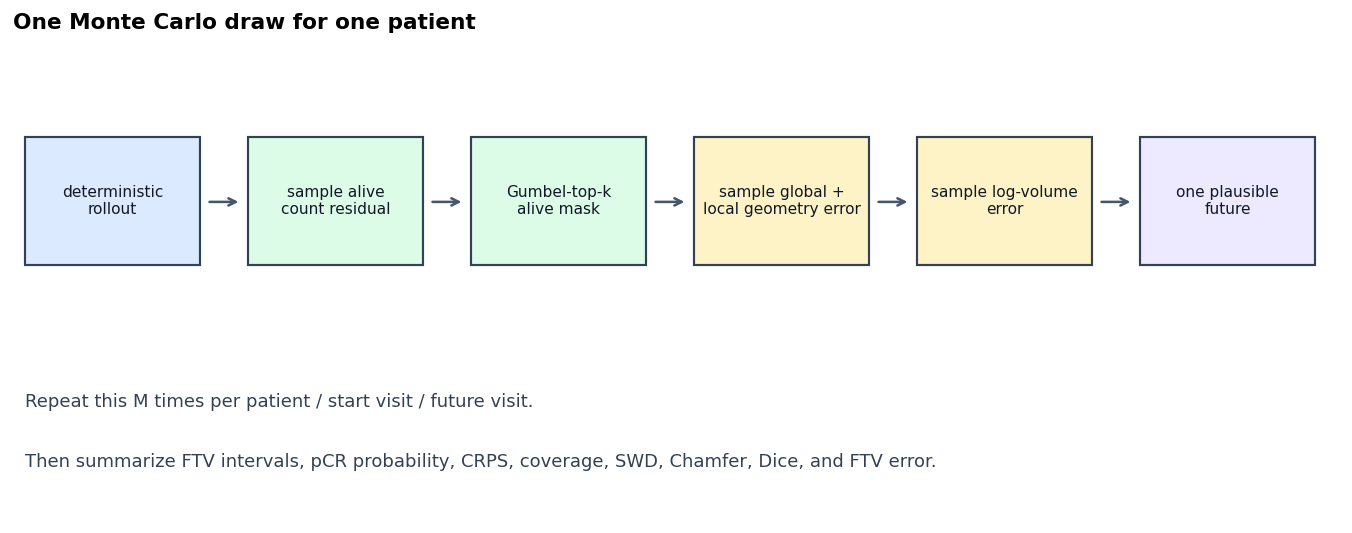

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.set_title("One Monte Carlo draw for one patient", loc="left", fontweight="bold")

items = [
    ("deterministic\nrollout", "#dbeafe"),
    ("sample alive\ncount residual", "#dcfce7"),
    ("Gumbel-top-k\nalive mask", "#dcfce7"),
    ("sample global +\nlocal geometry error", "#fef3c7"),
    ("sample log-volume\nerror", "#fef3c7"),
    ("one plausible\nfuture", "#ede9fe"),
]
xs = [0.1, 1.95, 3.8, 5.65, 7.5, 9.35]
for x0, (label, color) in zip(xs, items):
    draw_box(ax, (x0, 1.9), label, w=1.45, h=0.85, fc=color, fontsize=8.5)
for x0 in xs[:-1]:
    arrow(ax, (x0 + 1.47, 2.32), (x0 + 1.83, 2.32))

ax.text(0.1, 0.95, "Repeat this M times per patient / start visit / future visit.", fontsize=10, color="#334155")
ax.text(0.1, 0.55, "Then summarize FTV intervals, pCR probability, CRPS, coverage, SWD, Chamfer, Dice, and FTV error.", fontsize=10, color="#334155")
ax.set_xlim(0, 11.0)
ax.set_ylim(0.2, 3.4)
ax.axis("off")
plt.tight_layout()
plt.show()

## Notes for lab explanation

The short version I would say out loud:

> The rollout model itself is deterministic. Monte Carlo is our uncertainty wrapper. For a held-out patient, we first compute the model's mean future from the observed visits. Then we sample errors from other held-out patients with the same conditioning horizon, perturb survival, geometry, and volume, and obtain many plausible futures for that same patient. The output is a patient-specific predictive distribution. We then check whether the 90% intervals actually cover the observed FTV and whether uncertainty shrinks when we condition on later MRI visits.

The important caveat:

> These samples are empirical, residual-calibrated rollout distributions. The point is to quantify uncertainty around the current scheduled-sampling consistent rollout model.

Acronyms I should expand when presenting:

- **DCE-MRI**: dynamic contrast-enhanced magnetic resonance imaging.
- **SLIC**: simple linear iterative clustering, the supervoxel construction.
- **FTV**: functional tumor volume.
- **CRPS**: continuous ranked probability score.
- **SWD**: sliced Wasserstein distance.
- **pCR**: pathologic complete response; here we use $\mathrm{FTV}<0.1\,\mathrm{mL}$ as a proxy.

## Implementation pointer

The report artifacts are generated by:

```bash
python experiments/consistent_rollout/run_conditional_mc.py \
  --runs-dir runs/consistent_forecaster_v2/v2_sched_samp \
  --graphs-root datasets/ispy2/graphs_consistent \
  --n-mc 256 \
  --out-dir reports/conditional_mc_consistent_rollout
```

On Cradle we run the same thing through:

```bash
sbatch experiments/consistent_rollout/run_conditional_mc.sbatch
```

The expected output files are:

- `conditional_mc_samples.parquet`
- `conditional_mc_per_patient.parquet`
- `conditional_mc_summary.json`
- `conditional_mc_calibration.json`